# Heatmaps

To better understand the patterns of expression across samples, I'm going to plot heatmaps of DEGs in pairwise comparisons using the outputs from [filter_deseq_p2.v.p2.ipynb](https://github.com/jgmcdonough/CE24_RNA-seq/blob/main/analysis/diff_expression/phase2_v_phase2/new_refGenome/filter_deseq_p2.v.p2.ipynb)

## 0. load libraries

In [2]:
library(tidyverse)
library(pheatmap)

## 1. load csvs

### a. DEGs

In [3]:
# get list of files
files <- list.files(
    path = '/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/analysis/diff_expression/phase2_v_phase2/new_refGenome/deseq_res/prefilter_deseq/DEGs/',
    pattern = '\\.csv$',
    full.names = TRUE
    )

# Read each CSV and extract the DEG column
deg_list <- lapply(files, function(f) {
    df <- read.csv(f)
    df$Gene
})

# Name each list element
names(deg_list) <- tools::file_path_sans_ext(basename(files))

# Remove DEG_ prefix
names(deg_list) <- sub("^DEG_", "", names(deg_list))

names(deg_list)

[1] "bb_cc" "bc_bb" "bc_cc" "bc_hc" "bc_wc" "bh_ch" "bh_hh" "bw_cw" "bw_ww"
[10] "cb_bb" "cb_bc" "cb_cc" "cb_ch" "cb_cw" "ch_cc" "ch_hc" "cw_cc" "cw_ch"
[19] "cw_wc" "hb_bb" "hb_bh" "hb_cb" "hc_cc" "hc_hh" "hh_cc" "hh_ch" "wb_bb"
[28] "wb_bw" "wb_cb" "wc_cc" "wc_hc" "wc_ww" "wh_hw" "ww_cc" "ww_cw"

### b. vst
want a numeric matrix for `pheatmap`, with rows = genes and columns = samples

In [4]:
vst <- read.csv('/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/analysis/diff_expression/phase2_v_phase2/new_refGenome/deseq_res/prefilter_deseq/vst_filtered.csv') %>%
column_to_rownames('X')

dim(vst)
head(vst)

[1] 26060    94

,B1_B1_O01,B1_W5_O50,B2_B5_O51,B2_C4_O40,B3_B4_O41,B3_C3_O30,B3_C6_O66,B3_H4_O41,B3_W1_O06,B3_W4_O41,⋯,W4_W5_G56,W5_B2_G21,W5_C4_G45,W5_H4_G46,W5_W2_G22,W6_B3_G35,W6_B4_G48,W6_H6_G71,W6_W3_G36,W6_W4_G48
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
LOC144621260,11.788911,11.609006,11.595916,11.476810,11.234926,11.220484,11.559183,11.289794,11.379355,11.398233,⋯,11.981446,10.941294,11.330078,11.71853,11.599191,11.445385,11.562975,11.432241,11.957950,11.818873
LOC144621269,9.602056,11.379452,11.737743,10.859621,11.771901,10.978606,12.901227,11.294807,9.437976,9.329305,⋯,13.951508,9.279152,9.334302,10.61330,9.553586,9.788212,13.521587,9.422969,10.361229,13.500288
LOC111120925,9.656866,9.458665,10.401474,9.356832,9.420504,9.341876,9.170539,9.231583,9.170539,9.230573,⋯,10.301461,9.170539,9.286368,10.41541,9.692147,9.497548,9.314767,9.233722,9.377925,9.356685
LOC144621283,10.514534,10.842258,10.860578,10.724385,10.797540,11.020417,10.993201,10.409734,10.669010,10.746189,⋯,10.584652,10.953688,10.754090,10.86229,10.839297,10.773751,10.566906,11.246539,10.577775,10.601375
LOC144621276,13.523842,13.565088,13.730236,13.571161,13.837448,13.954453,13.775598,13.302441,13.816695,13.507726,⋯,14.075061,13.387790,13.906411,13.61466,13.187372,13.361386,13.987924,13.450197,13.493811,13.446814
LOC111115920,9.921277,9.969892,9.899101,9.789171,9.734002,9.697985,9.634951,10.313137,9.765185,10.213265,⋯,9.711852,9.775820,10.100357,9.86037,10.334120,10.336260,9.971320,10.085926,9.750364,9.827800


### c. meta data

In [5]:
meta <- read.csv('/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/metaData/sample_metaData.csv') %>%
# remove phase 1 samples
filter(Phase2_treatment != 'NA')

dim(meta)
head(meta)

[1] 96  9

,Sample,Phase1_treatment,Phase1_temp,Phase1_DO,Phase1_TankRep,Phase2_treatment,Phase2_temp,Phase2_DO,Phase2_TankRep
,<chr>,<chr>,<chr>,<chr>,<int>,<chr>,<chr>,<chr>,<int>
1,B1_B1_O01,both,warm,hypoxic,1,both,warm,hypoxic,1
2,B1_W5_O50,both,warm,hypoxic,1,warm,warm,normoxic,5
3,B2_B5_O51,both,warm,hypoxic,2,both,warm,hypoxic,5
4,B2_C4_O40,both,warm,hypoxic,2,control,ambient,normoxic,4
5,B3_B4_O41,both,warm,hypoxic,3,both,warm,hypoxic,4
6,B3_C3_O30,both,warm,hypoxic,3,control,ambient,normoxic,3


## 2. plot heatmap
using `pheatmap`

In [6]:
annotation <- meta %>%
  select(Sample, Phase1_treatment, Phase2_treatment) %>%
  column_to_rownames("Sample")

annotation <- annotation[colnames(vst), , drop = FALSE]

annotation_colors <- list(
  Phase1_treatment = c(
    control = "burlywood3",
    warm = "palevioletred",
      hypoxic = 'steelblue3',
      both = 'plum3'
  ),
  Phase2_treatment = c(
    control = "burlywood3",
    warm = "palevioletred",
      hypoxic = 'steelblue3',
      both = 'plum3'
  )
)

head(annotation)
head(annotation_colors)

,Phase1_treatment,Phase2_treatment
,<chr>,<chr>
B1_B1_O01,both,both
B1_W5_O50,both,warm
B2_B5_O51,both,both
B2_C4_O40,both,control
B3_B4_O41,both,both
B3_C3_O30,both,control


$Phase1_treatment
        control            warm         hypoxic            both 
   "burlywood3" "palevioletred"    "steelblue3"         "plum3" 

$Phase2_treatment
        control            warm         hypoxic            both 
   "burlywood3" "palevioletred"    "steelblue3"         "plum3"

make function to format input for `pheatmap`

### `get_vst_subset` function

In [41]:
get_vst_subset <- function(vst,
                           meta,
                           deg_list,
                           phase1_treatment,
                           phase2_treatment,
                           deg_column) {
  
  # Pull samples from metadata
  samples <- meta %>%
    filter(
      Phase2_treatment %in% phase2_treatment,
      Phase1_treatment %in% phase1_treatment
    ) %>%
    pull(Sample)
  
  # Subset VST by samples
  vst_subset <- vst[, colnames(vst) %in% samples, drop = FALSE]
  
  # Subset VST by DEGs
  vst_subset <- vst_subset[
    rownames(vst_subset) %in% deg_list[[deg_column]],
    ,
    drop = FALSE
  ]
  
  return(vst_subset)
}

### 1. effect of single exposure after period of recovery
- CC vs. WC (no enriched terms)
- CC vs. HC 
- CC vs. BC

**CC vs. WC**

In [27]:
cc_wc_vst <- get_vst_subset(
  vst = vst,
  meta = meta,
  deg_list = deg_list,
  phase1_treatment = c("warm", "control"),
  phase2_treatment = "control",
  deg_column = "wc_cc"
)
head(cc_wc_vst)

,C1_C4_W37,C2_C1_W03,C3_C2_W17,C4_C6_W67,C5_C3_W33,C6_C5_W59,W1_C1_G02,W1_C6_G61,W2_C2_G15,W3_C3_G29,W4_C5_G55,W5_C4_G45
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
LOC111127247,9.170539,9.170539,9.170539,9.170539,9.170539,9.170539,9.229372,9.170539,9.379925,9.281340,9.170539,9.170539
LOC111123050,9.260057,9.371131,9.362464,9.465197,9.361541,9.353668,9.272427,12.459720,9.341552,9.327197,9.464638,9.304275
LOC144617655,9.233843,9.231064,9.170539,9.260902,9.225713,9.170539,9.272427,9.220029,9.840875,9.281340,9.317779,9.963233
LOC111113307,9.260057,9.170539,9.170539,9.170539,9.170539,9.170539,10.071138,9.170539,10.009925,9.327197,9.721615,10.135554
LOC111109459,9.337944,9.275356,9.228445,9.308540,9.316463,9.329160,9.302058,9.326970,9.330519,9.313559,11.243325,9.320047
LOC144625005,9.170539,9.170539,9.170539,9.170539,9.170539,9.310445,10.617271,9.170539,10.430462,9.351402,11.516937,9.559404


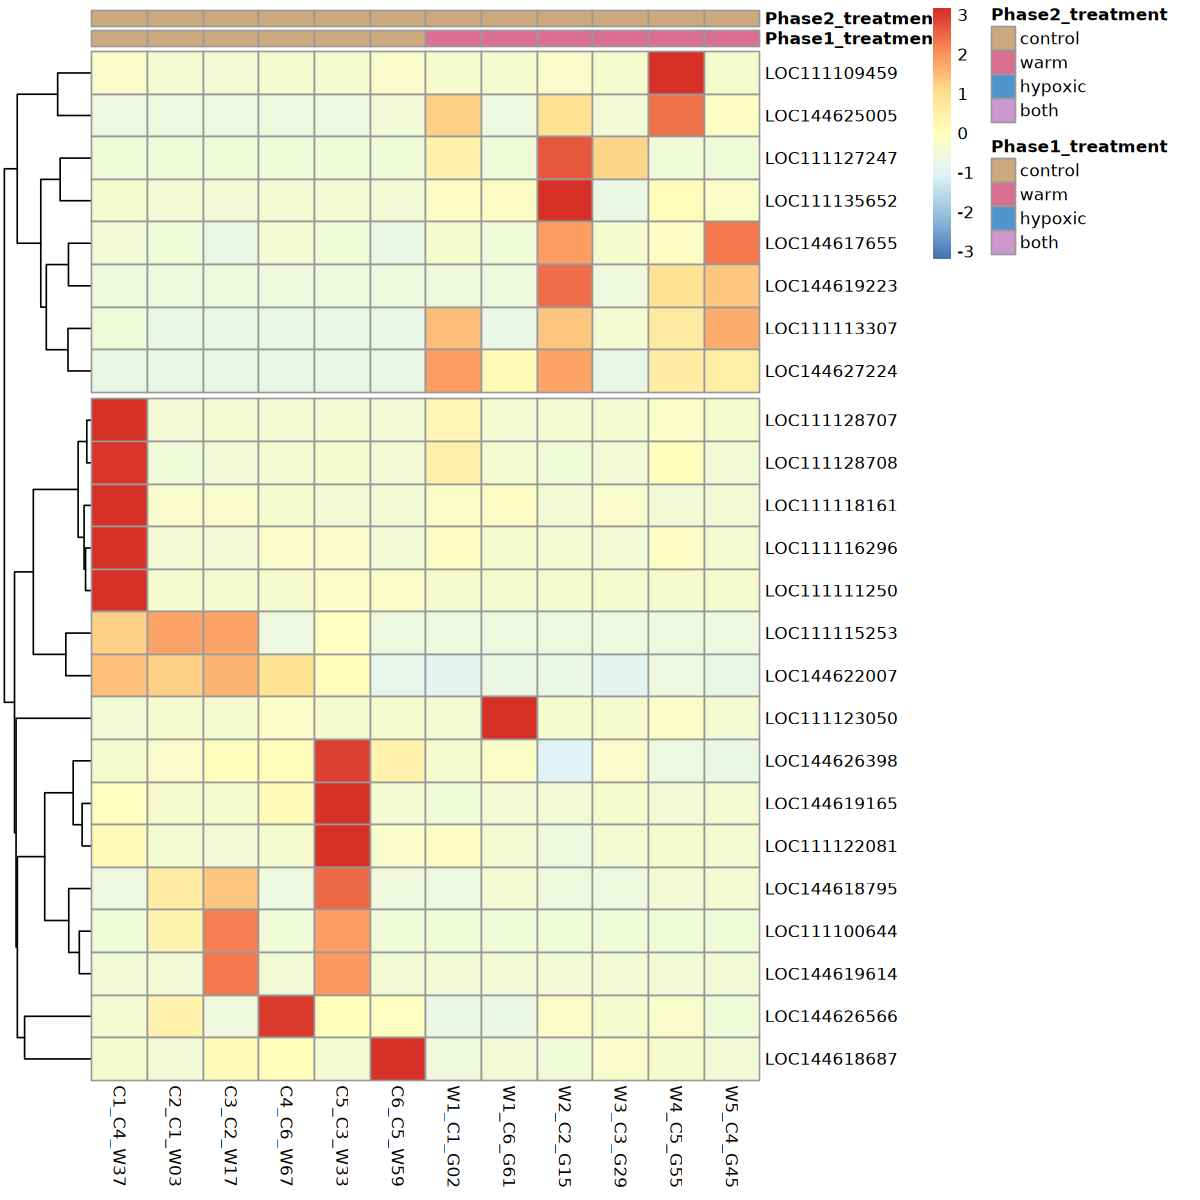

In [9]:
options(repr.plot.height = 10, repr.plot.width = 10)

pheatmap(cc_wc_vst,
         cluster_cols = FALSE,
        annotation_col = annotation,
         annotation_colors = annotation_colors,
         cutree_rows = 2, 
         cutree_cols = 2,
        scale = 'row' # standardizes each gene separately across samples
        ) 

**CC vs. HC**

In [28]:
cc_hc_vst <- get_vst_subset(
  vst = vst,
  meta = meta,
  deg_list = deg_list,
  phase1_treatment = c("hypoxic", "control"),
  phase2_treatment = "control",
  deg_column = "hc_cc"
)
head(cc_hc_vst)

,C1_C4_W37,C2_C1_W03,C3_C2_W17,C4_C6_W67,C5_C3_W33,C6_C5_W59,H1_C6_B62,H2_C1_B04,H3_C5_B54,H5_C2_B22,H5_C4_B46,H6_C3_B36
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
LOC144620744,9.492681,9.506791,9.415935,9.425831,9.353420,11.527939,9.386612,9.378691,9.329824,9.584844,9.402922,9.432164
LOC111101301,9.260057,9.472634,9.606095,14.593662,9.248563,13.024031,9.240701,9.464656,9.329824,9.300348,9.322763,9.409423
LOC111122501,11.123416,11.222821,10.987772,11.789298,10.989803,10.920344,14.696272,11.107479,14.019209,11.607863,12.203858,11.074545
LOC111127247,9.170539,9.170539,9.170539,9.170539,9.170539,9.170539,9.170539,9.228316,9.283199,9.170539,9.232708,9.170539
LOC111123678,9.170539,9.170539,9.170539,9.170539,9.170539,9.776157,9.170539,9.170539,9.170539,9.170539,9.170539,9.170539
LOC111113307,9.260057,9.170539,9.170539,9.170539,9.170539,9.170539,10.120495,9.170539,9.170539,9.714390,9.170539,9.849109


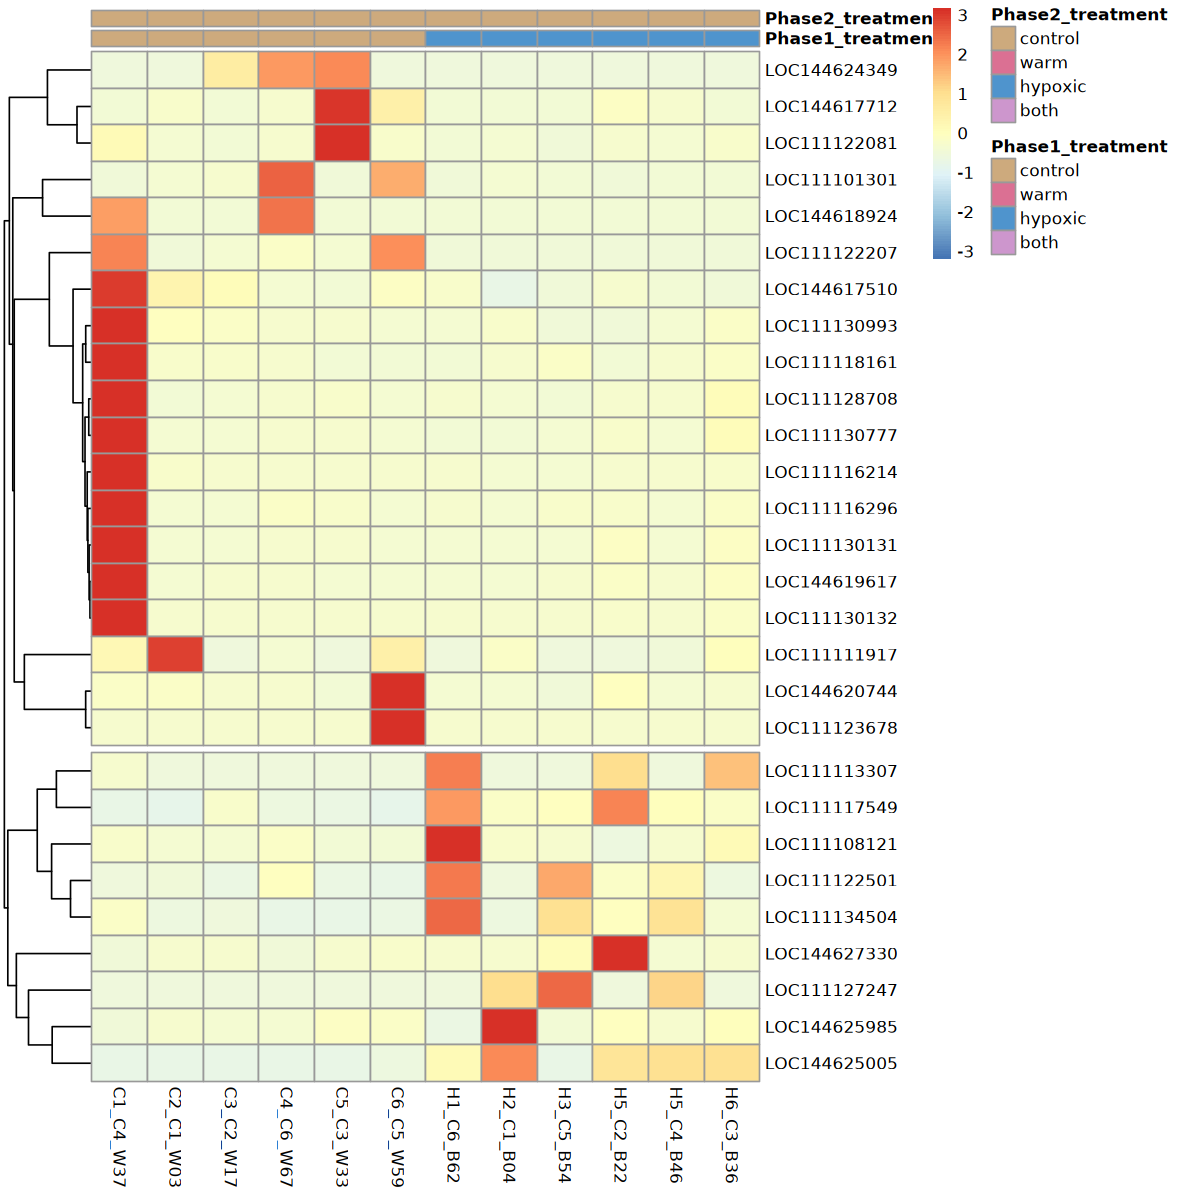

In [11]:
options(repr.plot.height = 10, repr.plot.width = 10)

pheatmap(cc_hc_vst,
         cluster_cols = FALSE,
        annotation_col = annotation,
         annotation_colors = annotation_colors,
         cutree_rows = 2, 
         cutree_cols = 2,
        scale = 'row' # standardizes each gene separately across samples
        ) 

**CC vs. BC**

In [29]:
cc_bc_vst <- get_vst_subset(
  vst = vst,
  meta = meta,
  deg_list = deg_list,
  phase1_treatment = c("both", "control"),
  phase2_treatment = "control",
  deg_column = "bc_cc"
)

head(cc_bc_vst)

,B2_C4_O40,B3_C3_O30,B3_C6_O66,B4_C5_O56,B6_C2_O24,C1_C4_W37,C2_C1_W03,C3_C2_W17,C4_C6_W67,C5_C3_W33,C6_C5_W59
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
LOC144618596,9.910217,10.303914,10.219308,10.025944,10.177979,9.579455,9.478595,9.688937,9.487297,9.578388,9.504364
LOC144619712,9.170539,9.170539,9.170539,9.170539,9.170539,9.170539,9.170539,9.170539,9.170539,9.920629,9.170539
LOC111102724,9.329441,9.235331,9.254753,9.170539,9.170539,9.170539,9.305838,10.219773,9.308540,10.083463,9.320096
LOC144623030,9.250020,9.235331,9.316360,9.308073,9.228367,10.798040,9.231064,9.323683,9.298310,12.192804,9.337731
LOC144623854,9.282928,9.170539,9.352367,9.170539,9.170539,9.654548,9.637359,9.286328,9.335455,9.543731,10.669665
LOC144625494,9.170539,9.170539,9.170539,9.170539,9.170539,9.170539,13.542014,9.170539,9.170539,9.794780,9.170539


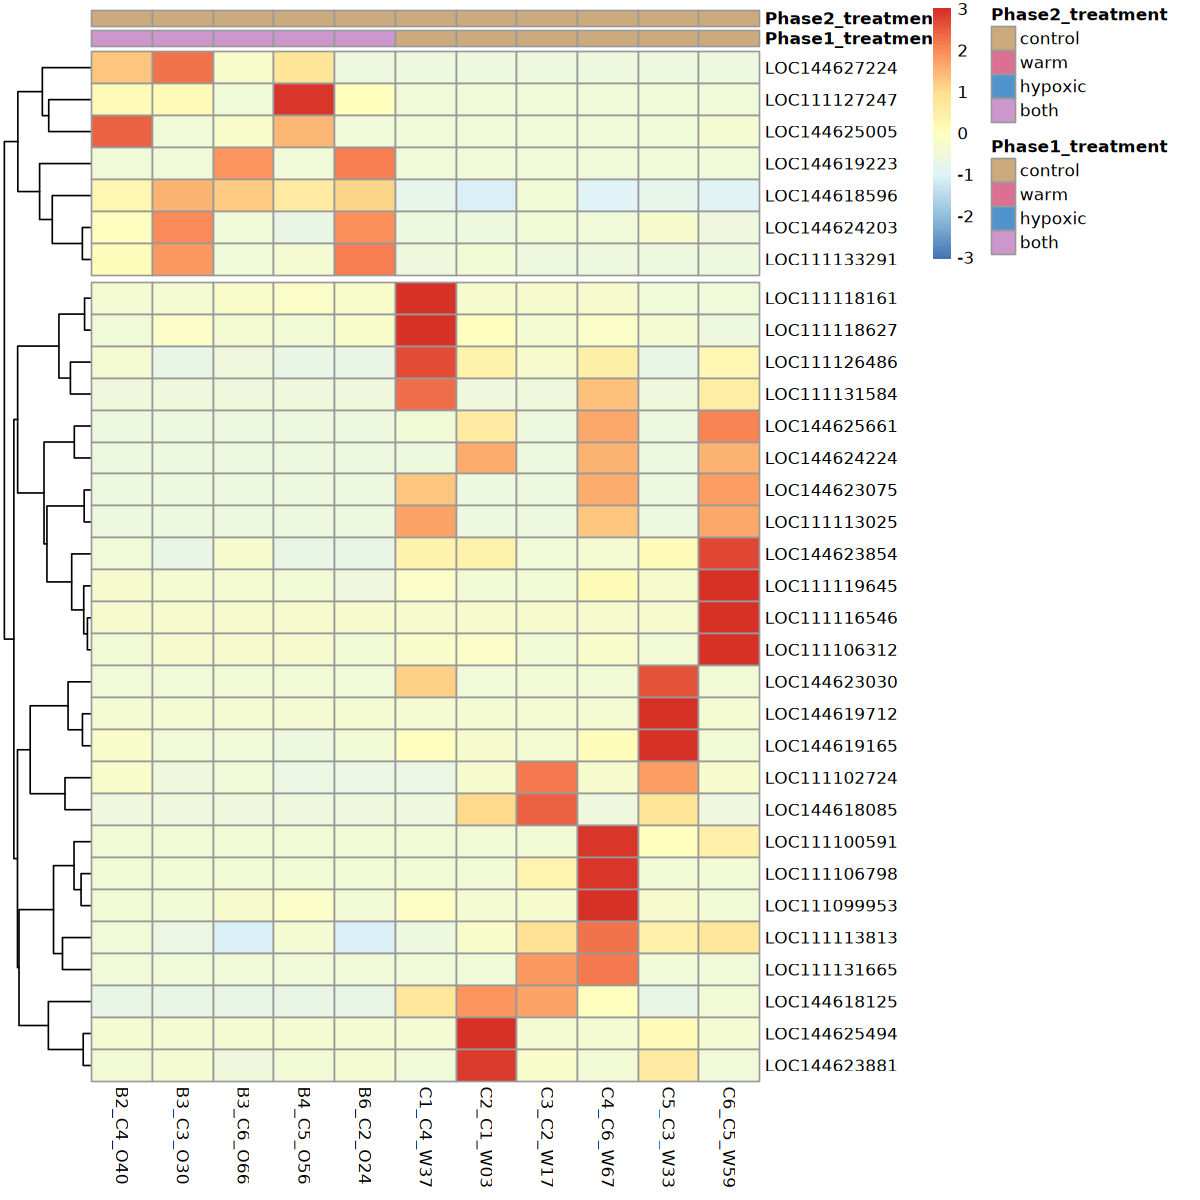

In [15]:
options(repr.plot.height = 10, repr.plot.width = 10)

pheatmap(cc_bc_vst,
         cluster_cols = FALSE,
        annotation_col = annotation,
         annotation_colors = annotation_colors,
         cutree_rows = 2, 
         cutree_cols = 2,
        scale = 'row' # standardizes each gene separately across samples
        ) 

### 2. effect of single exposure experienced only later in life
- CC vs. CW
- CC vs. CH
- CC vs. CB

**CC vs. CW**

In [42]:
cc_cw_vst <- get_vst_subset(
  vst = vst,
  meta = meta,
  deg_list = deg_list,
  phase2_treatment = c("warm", "control"),
  phase1_treatment = "control",
  deg_column = "cw_cc"
)

head(cc_cw_vst)

,C_W5_W52,C1_C4_W37,C2_C1_W03,C2_W2_W15,C3_C2_W17,C3_W3_W29,C4_C6_W67,C5_C3_W33,C5_W1_W09,C5_W4_W45,C6_C5_W59,C6_W6_W72
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
LOC111137262,11.397090,9.280166,9.341642,11.508448,9.270822,9.338288,9.244324,9.170539,9.231362,9.258414,9.288794,11.859585
LOC144619629,9.253212,9.510678,9.305838,9.257340,9.429175,9.233973,9.351176,9.417001,9.170539,9.170539,9.543560,9.170539
LOC111104612,9.170539,10.101802,15.278765,9.170539,12.794157,9.170539,15.988438,9.170539,9.170539,9.170539,9.170539,9.170539
LOC111105472,10.911003,9.349488,9.170539,11.138271,9.170539,9.170539,9.308540,9.170539,9.319470,9.376481,9.381951,9.341233
LOC144620744,9.404149,9.492681,9.506791,9.391656,9.415935,9.399032,9.425831,9.353420,9.428267,9.468056,11.527939,9.318386
LOC111103088,9.170539,9.280166,9.341642,9.276840,9.370985,10.401623,9.260902,9.344920,9.413563,9.376481,9.400881,9.404152


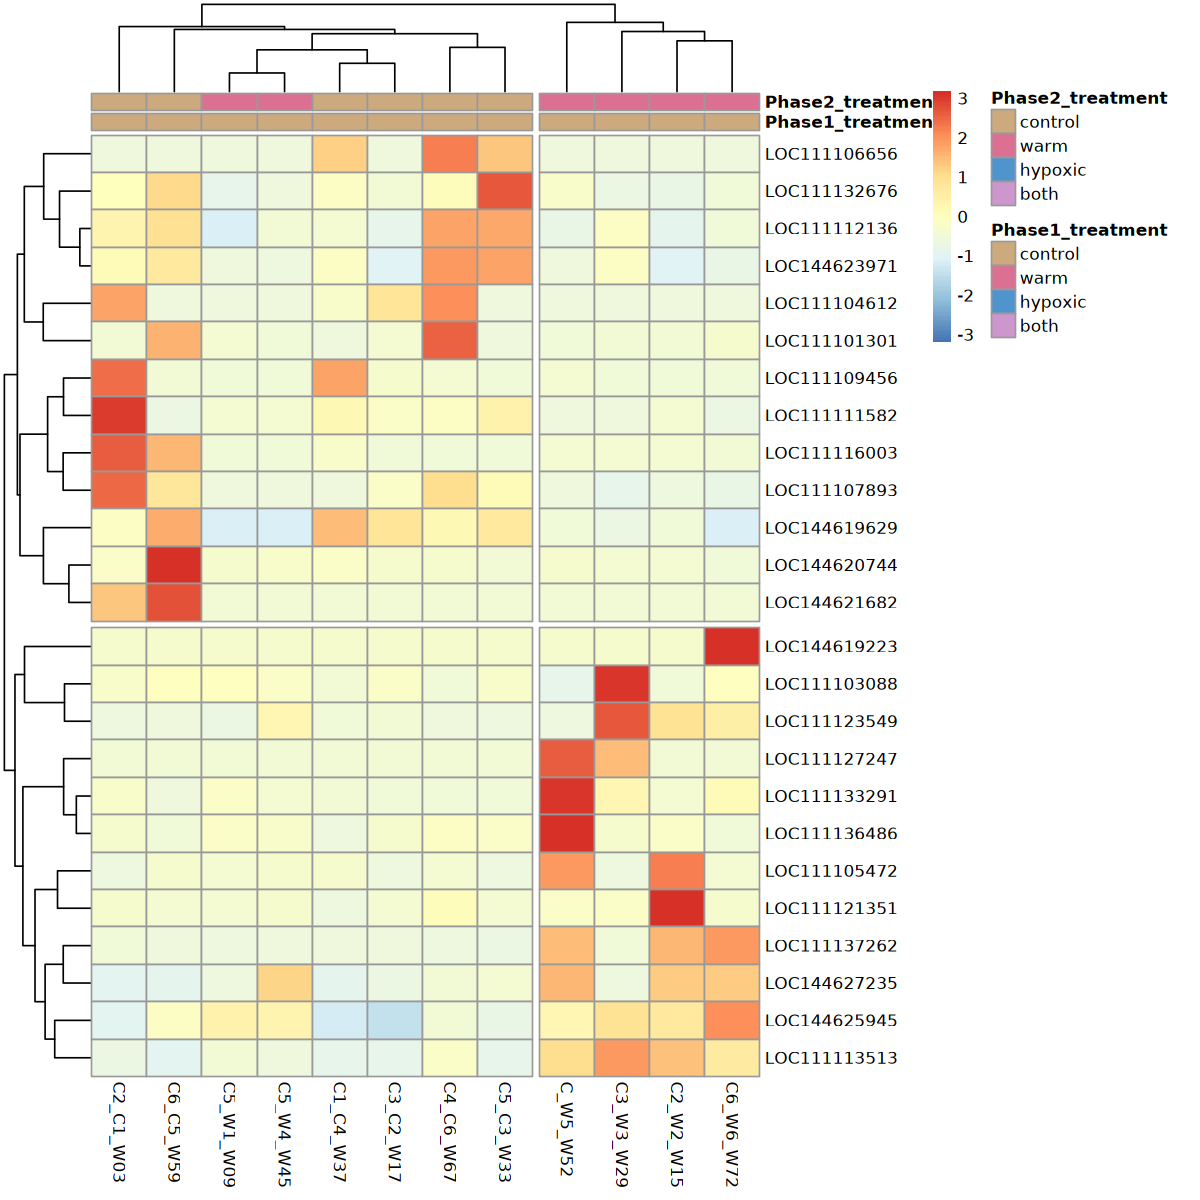

In [44]:
options(repr.plot.height = 10, repr.plot.width = 10)

pheatmap(cc_cw_vst,
        # cluster_cols = FALSE,
        annotation_col = annotation,
         annotation_colors = annotation_colors,
         cutree_rows = 2, 
         cutree_cols = 2,
         scale = 'row'
        ) 

**CC vs. HC**

In [45]:
cc_ch_vst <- get_vst_subset(
  vst = vst,
  meta = meta,
  deg_list = deg_list,
  phase2_treatment = c("hypoxic", "control"),
  phase1_treatment = "control",
  deg_column = "ch_cc"
)

head(cc_ch_vst)

,C1_C4_W37,C1_H2_W13,C1_H6_W62,C2_C1_W03,C2_H1_W04,C3_C2_W17,C4_C6_W67,C4_H5_W56,C5_C3_W33,C6_C5_W59,C6_H3_W36,C6_H4_W48
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
LOC111104083,10.303399,9.997248,10.309994,10.372961,10.181202,11.979973,10.033841,10.113007,10.156617,10.648284,10.091236,9.850131
LOC111104484,11.325658,9.696045,9.788061,9.952459,9.714548,10.011646,9.893462,9.767332,10.072459,10.011569,9.683074,9.797945
LOC111127247,9.170539,9.236076,9.170539,9.170539,9.170539,9.170539,9.170539,9.257736,9.170539,9.170539,9.170539,10.213422
LOC111125810,9.638000,9.170539,9.170539,9.256128,9.170539,9.252425,9.391701,9.170539,9.170539,9.288794,9.170539,9.170539
LOC111126116,13.127944,9.301578,9.312490,9.291563,9.725053,9.415935,9.318060,9.170539,9.361541,9.337731,9.170539,9.252508
LOC111111122,9.389636,10.394249,10.675088,9.490177,9.696551,9.487091,9.335455,10.639304,9.462016,9.641597,9.549971,9.587107


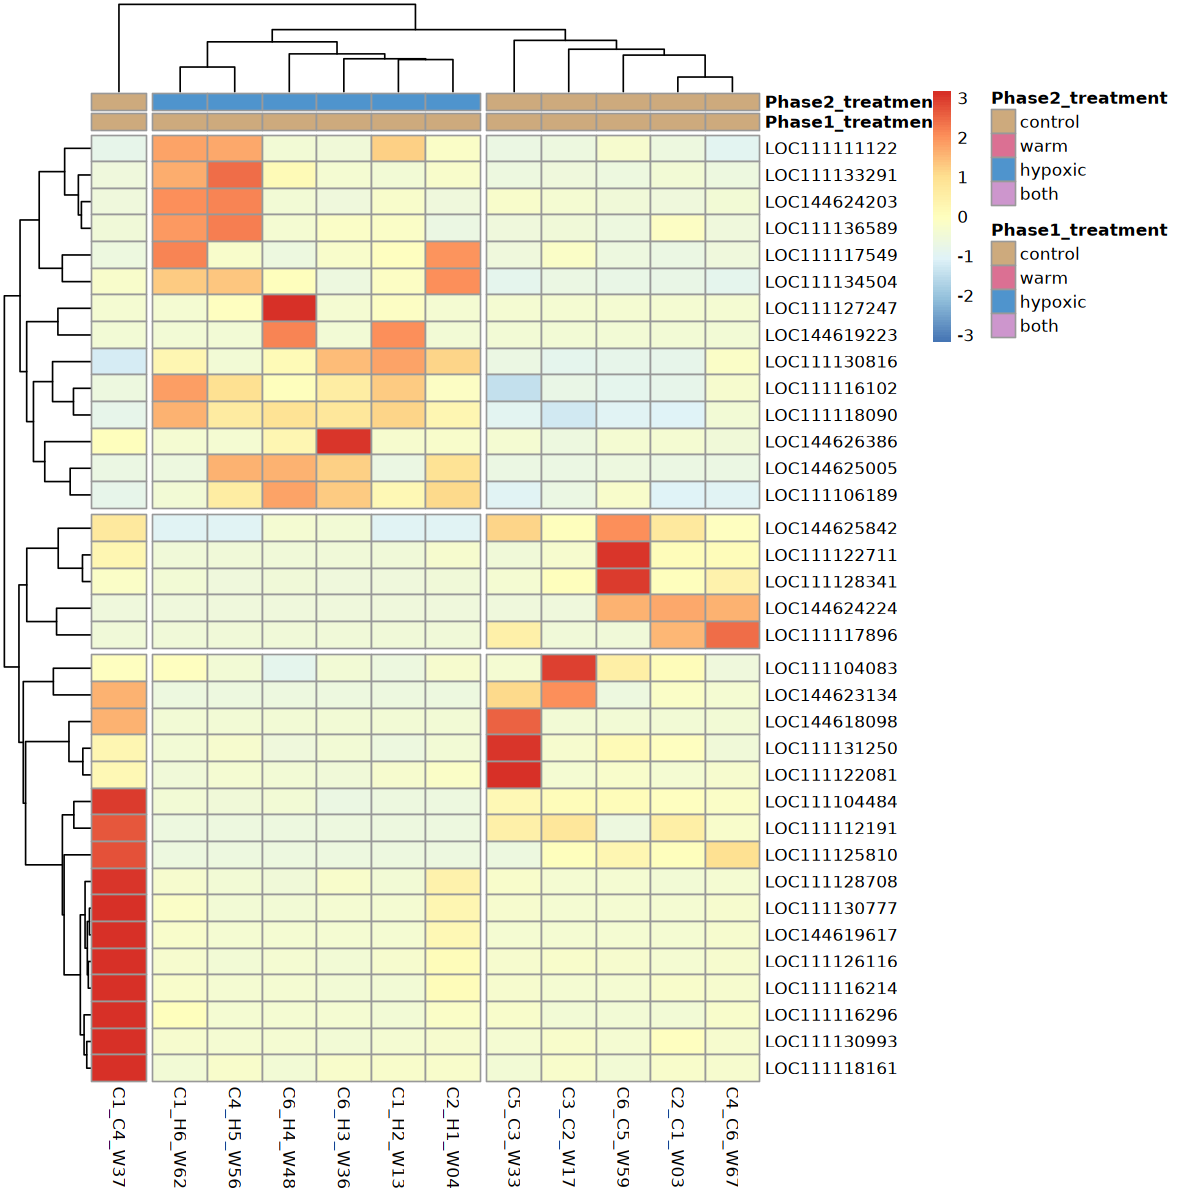

In [52]:
options(repr.plot.height = 10, repr.plot.width = 10)

pheatmap(cc_ch_vst,
        # cluster_cols = FALSE,
        annotation_col = annotation,
         annotation_colors = annotation_colors,
         cutree_rows = 3, 
         cutree_cols = 3,
         scale = 'row'
        ) 

okay so one sample (C1_C4_W37) specifically is driving the differences we see here ...

**CC vs. BC**

In [48]:
cc_cb_vst <- get_vst_subset(
  vst = vst,
  meta = meta,
  deg_list = deg_list,
  phase2_treatment = c("both", "control"),
  phase1_treatment = "control",
  deg_column = "cb_cc"
)

head(cc_cb_vst)

,C1_C4_W37,C2_B2_W16,C2_C1_W03,C3_B3_W30,C3_C2_W17,C4_B1_W07,C4_B5_W56,C4_C6_W67,C5_B4_W46,C5_C3_W33,C6_B6_W71,C6_C5_W59
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
LOC111117765,10.205654,10.705126,10.505353,10.923939,10.108985,11.200183,11.003537,10.520829,12.039593,10.094318,11.314646,10.208643
LOC111104797,9.939358,9.904932,9.920499,11.376995,9.792115,10.143714,11.061006,10.001968,11.170132,9.732384,11.522933,9.810996
LOC111100784,9.312045,9.383171,9.419798,9.392109,9.459606,9.378664,10.608276,9.409382,10.581158,9.410775,9.620528,9.320096
LOC111127247,9.170539,9.257411,9.170539,9.261069,9.170539,9.170539,9.170539,9.170539,9.170539,9.170539,9.327424,9.170539
LOC111123314,11.162780,12.377857,11.366642,12.740671,10.983461,12.385078,12.774308,11.573596,12.860218,11.045112,12.410789,11.073568
LOC111123050,9.260057,9.451635,9.371131,11.997512,9.362464,12.232901,9.432574,9.465197,9.469283,9.361541,9.489371,9.353668


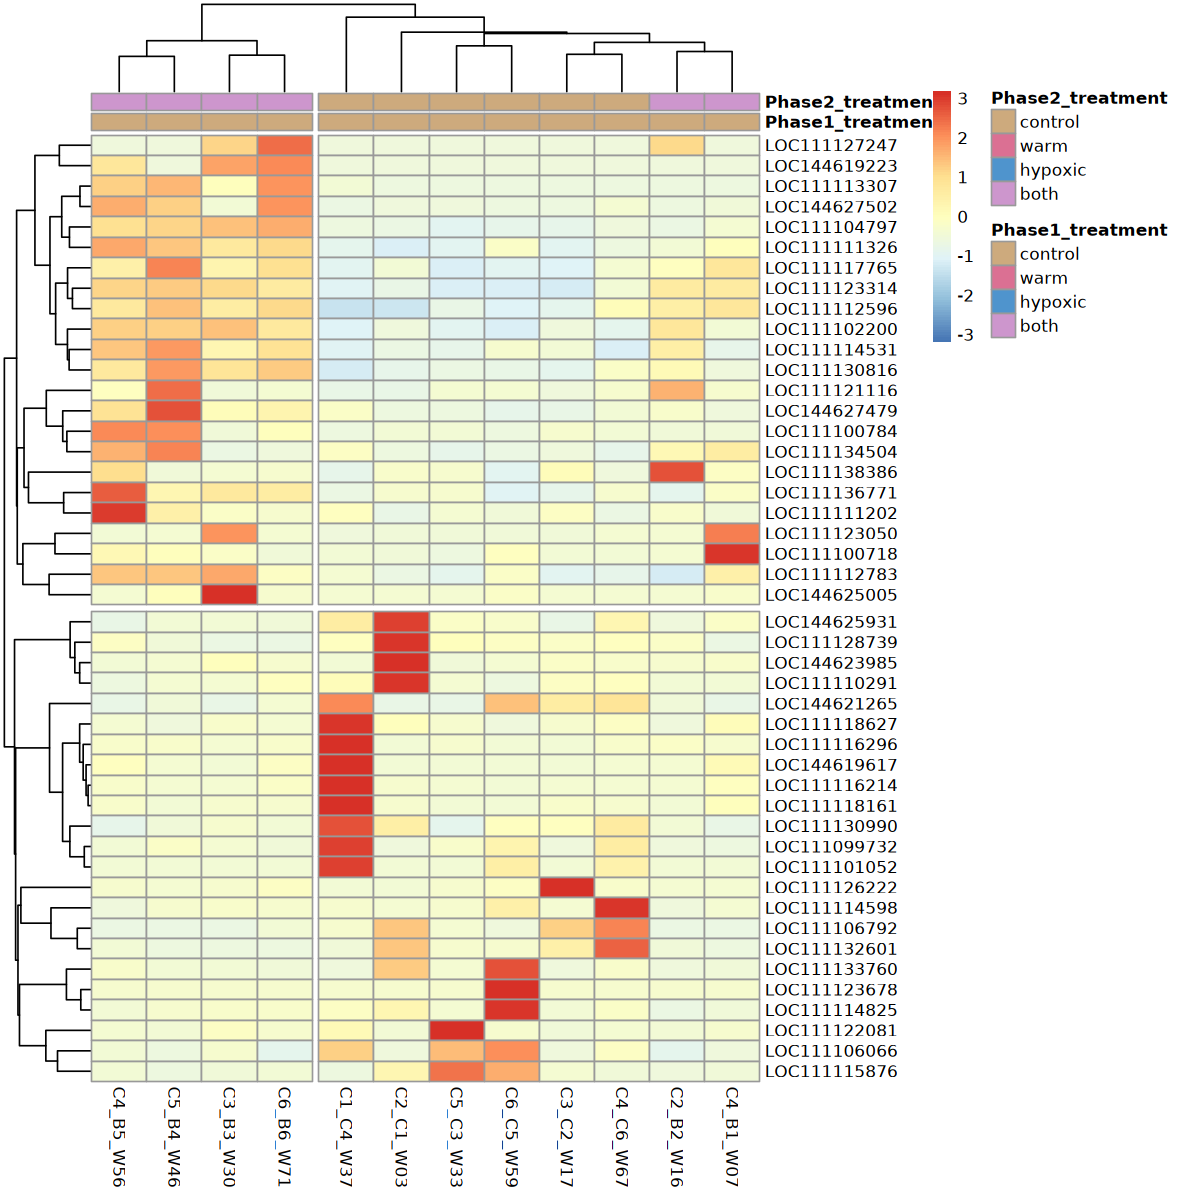

In [51]:
options(repr.plot.height = 10, repr.plot.width = 10)

pheatmap(cc_cb_vst,
        # cluster_cols = FALSE,
        annotation_col = annotation,
         annotation_colors = annotation_colors,
         cutree_rows = 2, 
         cutree_cols = 2,
         scale = 'row'
        ) 

this looks more convincing, at least for the genes with higher expression in the BC samples in the upper left (see more consistent coloring across multiple samples)